In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


Data and Parameters initialized successfully for a 1.0MW / 4.0MWh BESS system.
Degradation Cost Factor: €15.0 per MWh throughput.


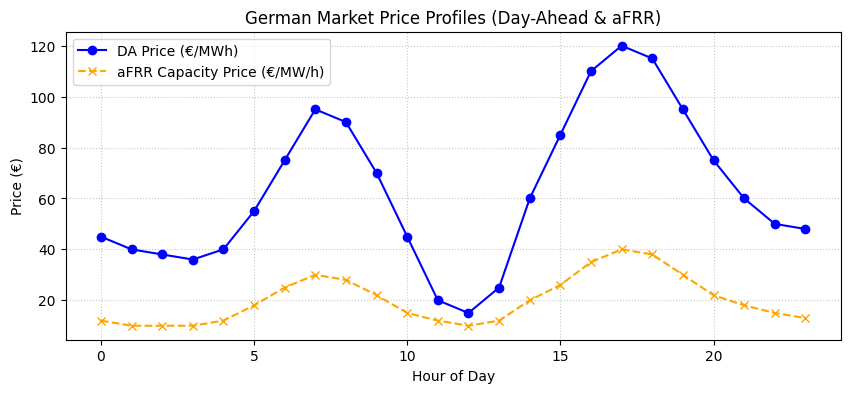

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# تنظیمات اولیه
np.random.seed(42)
n_hours = 24

# ۱. شبیه‌سازی قیمت‌های بازار آلمان (Day-Ahead & aFRR Capacity Price)
# قیمت Day-Ahead (€/MWh)
da_prices = np.array([
    45, 40, 38, 36, 40, 55,  # 00:00 - 05:00
    75, 95, 90, 70, 45, 20,  # 06:00 - 11:00
    15, 25, 60, 85, 110, 120,# 12:00 - 17:00
    115, 95, 75, 60, 50, 48  # 18:00 - 23:00
])

# قیمت ظرفیت بازار aFRR (آماده‌باش رزرو فرکانس - €/MW/h)
# معمولاً در ساعات پیک شبکه ارزش بالاتری دارد
afrr_capacity_prices = np.array([
    12, 10, 10, 10, 12, 18,
    25, 30, 28, 22, 15, 12,
    10, 12, 20, 26, 35, 40,
    38, 30, 22, 18, 15, 13
])

# ۲. مشخصات سیستم ذخیره‌ساز (BESS - باتری ۴ ساعته)
capacity_mwh = 4.0      # ظرفیت کل (MWh)
max_power_mw = 1.0      # حداکثر توان (MW) - باتری ۴ ساعته
eta_ch = 0.95           # راندمان شارژ
eta_dis = 0.95          # راندمان تخلیه

# ۳. مدل‌سازی هزینه استهلاک (Degradation Cost)
# فرض کنید هزینه تعویض پک باتری معادل مشخصی به ازای هر مگاوات‌ساعت انرژیِ ترانزیت‌شده (Throughput) است
# هزینه استهلاک به ازای هر مگاوات‌ساعت سیکل کامل شارژ و تخلیه (€ per MWh throughput)
degradation_cost_per_mwh = 15.0

print(f"Data and Parameters initialized successfully for a {max_power_mw}MW / {capacity_mwh}MWh BESS system.")
print(f"Degradation Cost Factor: €{degradation_cost_per_mwh} per MWh throughput.")

# رسم روند قیمت‌ها
plt.figure(figsize=(10, 4))
plt.plot(da_prices, label="DA Price (€/MWh)", color="blue", marker="o")
plt.plot(afrr_capacity_prices, label="aFRR Capacity Price (€/MW/h)", color="orange", linestyle="--", marker="x")
plt.title("German Market Price Profiles (Day-Ahead & aFRR)")
plt.xlabel("Hour of Day")
plt.ylabel("Price (€)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.7)
plt.show()

In [4]:
import pulp

# پارامترهای فنی تکمیلی
soc_min = 0.1 * capacity_mwh
soc_max = 0.9 * capacity_mwh
initial_soc = 0.5 * capacity_mwh

# ضریب فعال‌سازی aFRR (در بازار آلمان معمولاً تمام ظرفیت رزرو شده فراخوانده نمی‌شود. فرض: ۱۵٪ فعال‌سازی)
afrr_activation_rate = 0.15
hours = range(n_hours)

# تعریف مدل بهینه‌سازی MILP
model = pulp.LpProblem("Revenue_Stacking_Degradation", pulp.LpMaximize)

# ۱. متغیرهای تصمیم‌گیری
# مشارکت در Day-Ahead (مگاوات)
p_ch_da = pulp.LpVariable.dicts("P_ch_DA", hours, lowBound=0, upBound=max_power_mw)
p_dis_da = pulp.LpVariable.dicts("P_dis_DA", hours, lowBound=0, upBound=max_power_mw)

# مشارکت در رزرو فرکانس aFRR (مگاوات ظرفیت رزرو شده)
r_up_afrr = pulp.LpVariable.dicts("R_up_aFRR", hours, lowBound=0, upBound=max_power_mw)
r_down_afrr = pulp.LpVariable.dicts("R_down_aFRR", hours, lowBound=0, upBound=max_power_mw)

# وضعیت شارژ باتری (مگاوات‌ساعت)
soc = pulp.LpVariable.dicts("SoC", hours, lowBound=soc_min, upBound=soc_max)

# ۲. توابع مالی
# مجموع درآمدهای ناخالص
revenue_da = pulp.lpSum(da_prices[t] * (p_dis_da[t] - p_ch_da[t]) for t in hours)
revenue_afrr = pulp.lpSum(afrr_capacity_prices[t] * (r_up_afrr[t] + r_down_afrr[t]) for t in hours)

# محاسبه هزینه استهلاک بر اساس حجم کل انرژی ترانزیت‌شده (Throughput)
throughput = pulp.lpSum(
    p_ch_da[t] + p_dis_da[t] + afrr_activation_rate * (r_up_afrr[t] + r_down_afrr[t])
    for t in hours
)
degradation_cost = degradation_cost_per_mwh * throughput

# تابع هدف: بیشینه‌سازی سود خالص (Net Profit)
model += (revenue_da + revenue_afrr) - degradation_cost

# ۳. قیود سیستمی و فیزیکی
for t in hours:
    # قید محدودیت توان (Power Capacity Stack)
    # مجموع توان درگیر در DA و ظرفیت رزرو شده برای aFRR نباید از توان نامی اینورتر فراتر رود
    model += p_dis_da[t] + r_up_afrr[t] <= max_power_mw
    model += p_ch_da[t] + r_down_afrr[t] <= max_power_mw

    # قید دینامیک انرژی (SoC Update)
    net_power = (eta_ch * (p_ch_da[t] + afrr_activation_rate * r_down_afrr[t])) - \
                ((p_dis_da[t] + afrr_activation_rate * r_up_afrr[t]) / eta_dis)

    if t == 0:
        model += soc[t] == initial_soc + net_power * 1.0
    else:
        model += soc[t] == soc[t-1] + net_power * 1.0

    # قید تضمین انرژی (Energy Availability for aFRR)
    # باتری باید همواره ظرفیت کافی برای تامین حداقل ۱ ساعت کامل از سرویس aFRR تعهد داده شده را داشته باشد
    model += soc[t] - (r_up_afrr[t] / eta_dis) * 1.0 >= soc_min
    model += soc[t] + (eta_ch * r_down_afrr[t]) * 1.0 <= soc_max

# حل مسئله
model.solve(pulp.PULP_CBC_CMD(msg=0))

print("--- Revenue Stacking Optimization Results ---")
print(f"Status:            {pulp.LpStatus[model.status]}")
print(f"Gross DA Revenue:  €{revenue_da.value():.2f}")
print(f"Gross aFRR Revenue:€{revenue_afrr.value():.2f}")
print(f"Total Gross Rev:   €{revenue_da.value() + revenue_afrr.value():.2f}")
print(f"Degradation Cost: -€{degradation_cost.value():.2f}")
print(f"Net Profit:        €{model.objective.value():.2f}")

--- Revenue Stacking Optimization Results ---
Status:            Optimal
Gross DA Revenue:  €359.59
Gross aFRR Revenue:€734.21
Total Gross Rev:   €1093.80
Degradation Cost: -€158.61
Net Profit:        €935.19


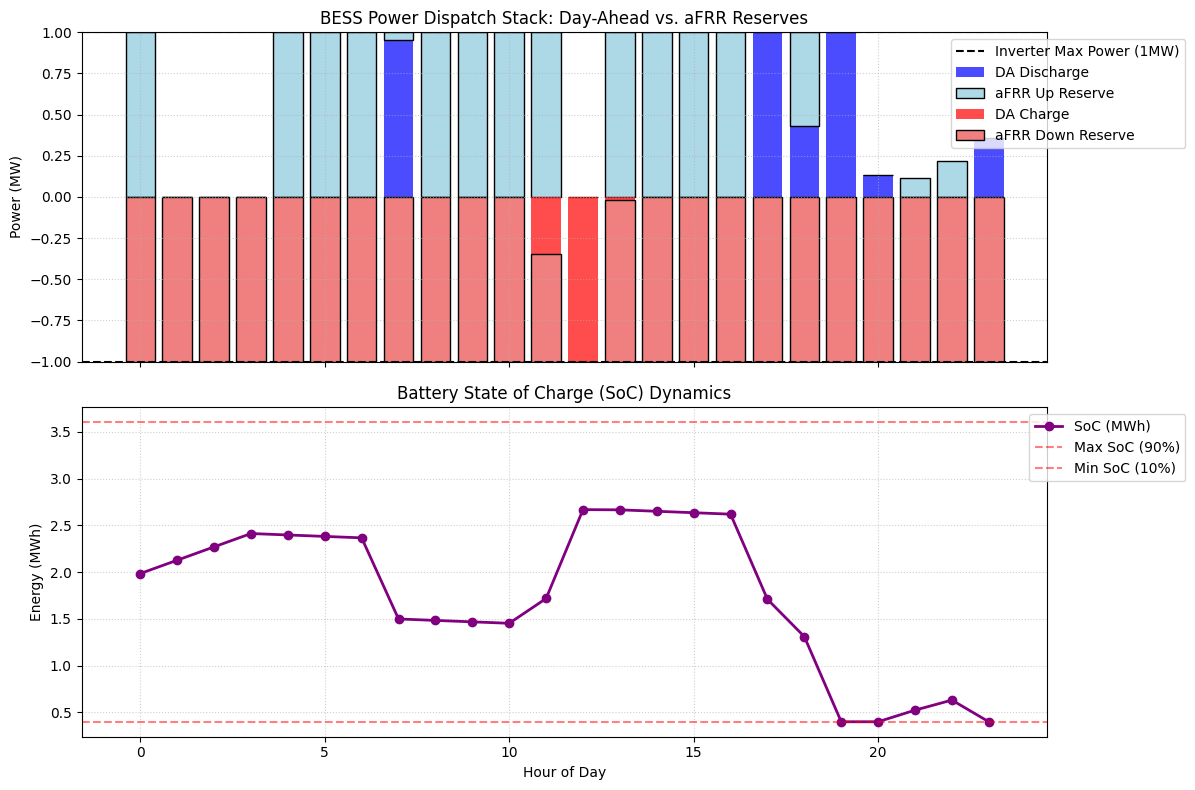


--- Financial Summary ---
             Metric   Value (€)
   Gross DA Revenue  359.592714
 Gross aFRR Revenue  734.210667
Total Gross Revenue 1093.803382
   Degradation Cost -158.610041
         Net Profit  935.193340


In [5]:
# استخراج مقادیر بهینه‌شده از متغیرهای مدل
p_ch_da_vals = [p_ch_da[t].value() for t in hours]
p_dis_da_vals = [p_dis_da[t].value() for t in hours]
r_up_afrr_vals = [r_up_afrr[t].value() for t in hours]
r_down_afrr_vals = [r_down_afrr[t].value() for t in hours]
soc_vals = [soc[t].value() for t in hours]

# ایجاد نمودارهای تحلیلی (Dispatch & SoC)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 1. نمودار توان (Power Dispatch Stack)
# سمت دیسپچ/تخلیه (بالای محور X)
ax1.bar(hours, p_dis_da_vals, label='DA Discharge', color='blue', alpha=0.7)
ax1.bar(hours, r_up_afrr_vals, bottom=p_dis_da_vals, label='aFRR Up Reserve', color='lightblue', edgecolor='black')

# سمت شارژ (پایین محور X - منفی نشان داده می‌شود)
ax1.bar(hours, [-x for x in p_ch_da_vals], label='DA Charge', color='red', alpha=0.7)
ax1.bar(hours, [-x for x in r_down_afrr_vals], bottom=[-x for x in p_ch_da_vals], label='aFRR Down Reserve', color='lightcoral', edgecolor='black')

ax1.axhline(max_power_mw, color='black', linestyle='--', linewidth=1.5, label='Inverter Max Power (1MW)')
ax1.axhline(-max_power_mw, color='black', linestyle='--', linewidth=1.5)
ax1.set_ylabel('Power (MW)')
ax1.set_title('BESS Power Dispatch Stack: Day-Ahead vs. aFRR Reserves')
ax1.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. نمودار وضعیت شارژ (State of Charge - SoC)
ax2.plot(hours, soc_vals, color='purple', marker='o', linewidth=2, label='SoC (MWh)')
ax2.axhline(soc_max, color='red', linestyle='--', alpha=0.5, label='Max SoC (90%)')
ax2.axhline(soc_min, color='red', linestyle='--', alpha=0.5, label='Min SoC (10%)')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Energy (MWh)')
ax2.set_title('Battery State of Charge (SoC) Dynamics')
ax2.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# نمایش جدول خلاصه اقتصادی برای مستندات
summary_df = pd.DataFrame({
    "Metric": ["Gross DA Revenue", "Gross aFRR Revenue", "Total Gross Revenue", "Degradation Cost", "Net Profit"],
    "Value (€)": [revenue_da.value(), revenue_afrr.value(), revenue_da.value() + revenue_afrr.value(), -degradation_cost.value(), model.objective.value()]
})
print("\n--- Financial Summary ---")
print(summary_df.to_string(index=False))

In [6]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt

# ۱. ایجاد پوشه خروجی‌ها
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# ۲. رسم و ذخیره نمودار اول: قیمت‌های بازار
fig1 = plt.figure(figsize=(10, 4))
plt.plot(da_prices, label="DA Price (€/MWh)", color="blue", marker="o")
plt.plot(afrr_capacity_prices, label="aFRR Capacity Price (€/MW/h)", color="orange", linestyle="--", marker="x")
plt.title("German Market Price Profiles (Day-Ahead & aFRR)")
plt.xlabel("Hour of Day")
plt.ylabel("Price (€)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.7)
fig1.savefig(os.path.join(output_dir, "market_prices_afrr_da.png"), dpi=300, bbox_inches='tight')
plt.close(fig1) # بستن نمودار برای جلوگیری از نمایش مجدد و اشغال حافظه

# ۳. رسم و ذخیره نمودار دوم: دیسپچ توان و وضعیت شارژ
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# دیسپچ توان
ax1.bar(hours, p_dis_da_vals, label='DA Discharge', color='blue', alpha=0.7)
ax1.bar(hours, r_up_afrr_vals, bottom=p_dis_da_vals, label='aFRR Up Reserve', color='lightblue', edgecolor='black')
ax1.bar(hours, [-x for x in p_ch_da_vals], label='DA Charge', color='red', alpha=0.7)
ax1.bar(hours, [-x for x in r_down_afrr_vals], bottom=[-x for x in p_ch_da_vals], label='aFRR Down Reserve', color='lightcoral', edgecolor='black')
ax1.axhline(max_power_mw, color='black', linestyle='--', linewidth=1.5, label='Inverter Max Power (1MW)')
ax1.axhline(-max_power_mw, color='black', linestyle='--', linewidth=1.5)
ax1.set_ylabel('Power (MW)')
ax1.set_title('BESS Power Dispatch Stack: Day-Ahead vs. aFRR Reserves')
ax1.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax1.grid(True, linestyle=':', alpha=0.6)

# وضعیت شارژ باتری
ax2.plot(hours, soc_vals, color='purple', marker='o', linewidth=2, label='SoC (MWh)')
ax2.axhline(soc_max, color='red', linestyle='--', alpha=0.5, label='Max SoC (90%)')
ax2.axhline(soc_min, color='red', linestyle='--', alpha=0.5, label='Min SoC (10%)')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Energy (MWh)')
ax2.set_title('Battery State of Charge (SoC) Dynamics')
ax2.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
fig2.savefig(os.path.join(output_dir, "dispatch_and_soc_dynamics.png"), dpi=300, bbox_inches='tight')
plt.close(fig2)

# ۴. تولید و ذخیره جدول خلاصه مالی (CSV)
summary_df = pd.DataFrame({
    "Metric": ["Gross DA Revenue", "Gross aFRR Revenue", "Total Gross Revenue", "Degradation Cost", "Net Profit"],
    "Value (€)": [round(revenue_da.value(), 2), round(revenue_afrr.value(), 2),
                  round(revenue_da.value() + revenue_afrr.value(), 2),
                  round(-degradation_cost.value(), 2), round(model.objective.value(), 2)]
})
summary_df.to_csv(os.path.join(output_dir, "financial_summary.csv"), index=False)

# ۵. فشرده‌سازی پوشه خروجی‌ها برای دانلود آسان
shutil.make_archive("BESS_Outputs", 'zip', output_dir)

print(f"✅ تمام فایل‌ها در پوشه '{output_dir}' ذخیره شدند.")
print("📦 فایل 'BESS_Outputs.zip' ساخته شد و اکنون آماده دانلود است!")

✅ تمام فایل‌ها در پوشه 'outputs' ذخیره شدند.
📦 فایل 'BESS_Outputs.zip' ساخته شد و اکنون آماده دانلود است!
